# Stock Price Predictor using Machine Learning

Initial imports

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf       # yahoo finance API from which we will get our data
import matplotlib.pyplot as plt     # Visualization

import torch        # Deep learning library
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler        # scale and...
from sklearn.metrics import root_mean_squared_error     # ... evaluation

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.125275  296.143523  293.992323  294.912966  59151200
2020-01-03  293.882965  295.004144  292.688877  292.743566  77709700
2020-01-06  295.004181  295.086214  292.014370  292.132872  55653900
2020-01-07  294.174652  294.912981  293.727989  294.438973  40496400
2020-01-08  295.742432  296.954740  294.119928  294.366029  68296000
...                ...         ...         ...         ...       ...
2026-09-10  757.830017  760.109985  756.640015  758.030029  42740400
2026-09-11  764.289978  766.380005  763.599976  764.719971  45512700
2026-09-14  760.880005  763.520020  757.929993  759.000000  43992400
2026-09-15  757.390015  760.349976  756.150024  760.119995  46195000
2026-09-16  754.049988  761.669983  749.599976  759.500000  58959700

[1685 rows x 5 columns]


<Axes: xlabel='Date'>

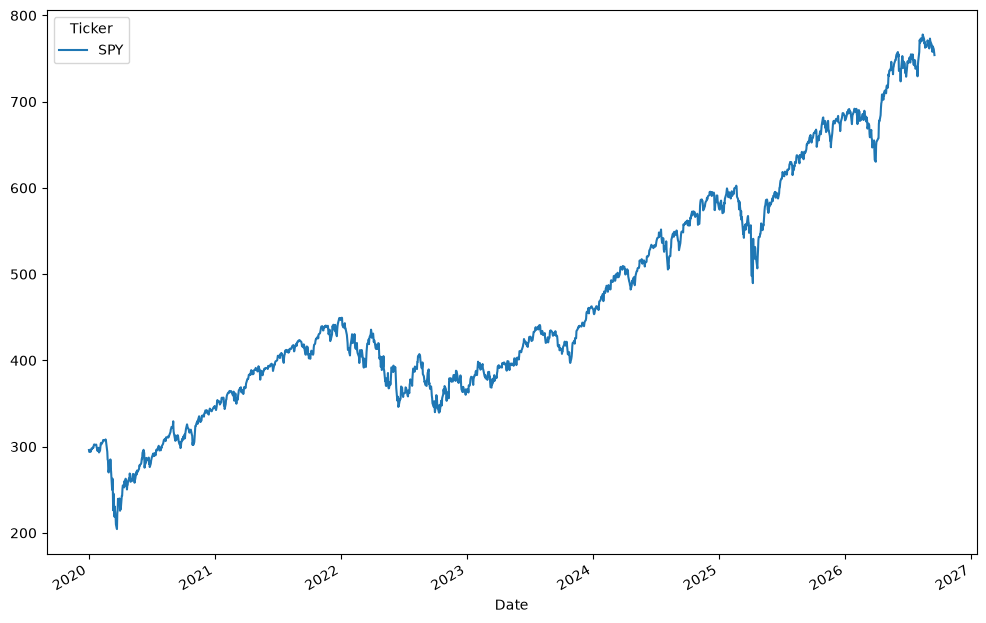

In [4]:
# Ideally, we want to use a CUDA supported GPU, but if unavailable, we can use any CPU
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Next we want to take our ticker, in this case SPY, and load the ticker data into a dataframe starting from january of 2020
ticker = 'SPY'
df = yf.download(ticker, '2020-01-01')
print(df)

# Plotting the Close prices of SPY
df.Close.plot(figsize=(12, 8))

We've taken our data from the yfinance import, loaded it into a dataframe and plotted the points. Our plan is to cut 80% of that data to train our model, and use it to predict or test it against the last 20% or so.

In [5]:
# We will create a scaler object to standardize our data
scaler = StandardScaler()

# Remove the mean from our x and scaling to unit variance dividing by standard deviation
std_df = pd.DataFrame(scaler.fit_transform(df['Close']))
print(std_df)

             0
0    -1.279972
1    -1.296682
2    -1.288326
3    -1.294508
4    -1.282825
...        ...
1680  2.160708
1681  2.208848
1682  2.183437
1683  2.157429
1684  2.132539

[1685 rows x 1 columns]


We want to show our model the previous 29 days, then have it predict the 30th day. 

In [ ]:
seq_length = 30
data = []

# Looking at 29 days and predicting the last day
# The outer array (data[]) contains arrays of 30 days, and those days are themselves, arrays
for i in range(len(std_df) - seq_length):
    data.append(std_df[i:i+seq_length])

data = np.array(data)
data

array([[[-1.27997181],
        [-1.29668177],
        [-1.28832633],
        ...,
        [-1.20939566],
        [-1.1947227 ],
        [-1.19716816]],

       [[-1.29668177],
        [-1.28832633],
        [-1.29450808],
        ...,
        [-1.1947227 ],
        [-1.19716816],
        [-1.19349986]],

       [[-1.28832633],
        [-1.29450808],
        [-1.2828248 ],
        ...,
        [-1.19716816],
        [-1.19349986],
        [-1.19940916]],

       ...,

       [[ 2.08022511],
        [ 2.15951533],
        [ 2.26131156],
        ...,
        [ 2.19476417],
        [ 2.16070793],
        [ 2.20884834]],

       [[ 2.15951533],
        [ 2.26131156],
        [ 2.24983501],
        ...,
        [ 2.16070793],
        [ 2.20884834],
        [ 2.1834368 ]],

       [[ 2.26131156],
        [ 2.24983501],
        [ 2.24066904],
        ...,
        [ 2.20884834],
        [ 2.1834368 ],
        [ 2.15742897]]], shape=(1655, 30, 1))

Test/Train Split

We are interested in sequential prediction

In [7]:
train_size = int(.8 * len(data))    # training on only 80% of our data

x_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)   # up until the last index
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)    # only the last index
x_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [8]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device = device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device = device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [9]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=.01)

In [11]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(x_train)   # make a prediction

    loss = criterion(y_train_pred, y_train) # see how accurate our prediction is

    if i % 25 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 0.6994863152503967
25 0.011655326932668686
50 0.003920470830053091
75 0.0027435114607214928
100 0.0025205176789313555
125 0.0024038085248321295
150 0.002309798961505294
175 0.0022284945007413626


In [12]:
model.eval()

y_test_pred = model(x_test)

#inverse scale
y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])
print(train_rmse)
print(test_rmse)

6.234218120574951
36.29006576538086


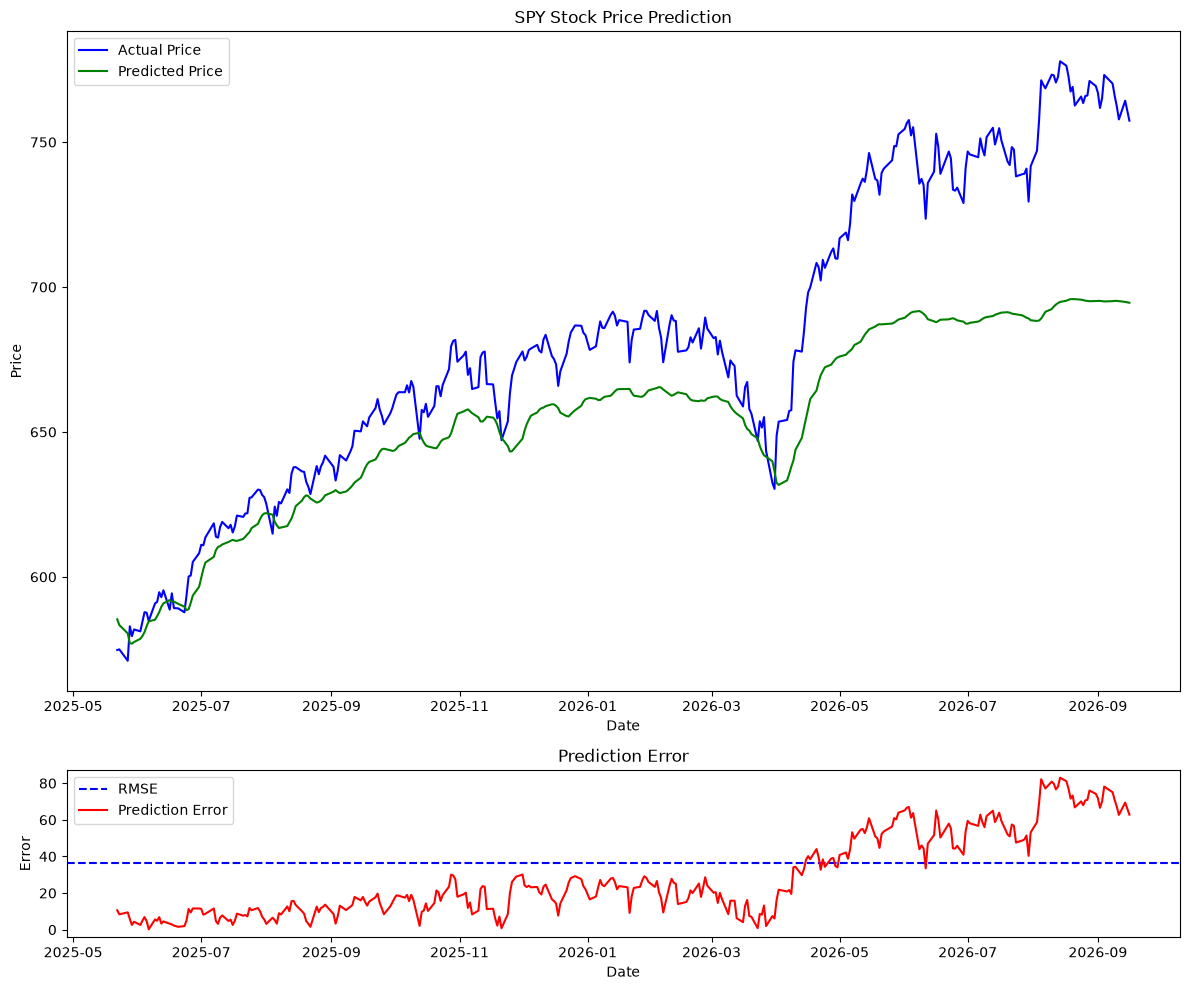

In [13]:
fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,1)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color = 'blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()

plt.show()


Prediction line lags behind, shifts to the right. Model adjust after a day has happend. After a movement the model picks up on it. RMSE shows us that as time goes on, our prediction model measures more error.